<a href="https://colab.research.google.com/github/kevinwaskitaa/tugas-kuliah-teknologi-komputer/blob/main/Game_Buta_Warna_dan_Klasifikasi_Kucing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Nama : Kevin A**
# **NIM : 24030005**

**1. Buat pendeteksian game buta warna menggunakan phyton di google colab.**
**Kevin : Warna: Orange. Coklat, abu-abu**


In [1]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import random
import time

# 3 Warna target yang akan muncul di gambar kotak
warna_kevin = ["Orange", "Coklat", "Abu-abu"]

# 8 Pilihan warna yang akan muncul di menu dropdown pembantu/pengecoh
semua_pilihan = ["Orange", "Pink", "Biru", "Coklat", "Abu-abu", "Hitam", "Putih", "Ungu"]

# Kode warna hex untuk visualisasi kotak gambar
kode_warna = {
    "Orange": "#FFA500", "Coklat": "#A52A2A", "Abu-abu": "#808080",
    "Pink": "#FFC0CB", "Biru tua": "#000080", "Hitam": "#000000",
    "Biru laut": "#00FFFF", "Ungu": "#800080"
}

# Membuat daftar 10 soal acak dari warna Kevin
daftar_soal = random.choices(warna_kevin, k=10)

# Variabel permainan
skor = 0
indeks_soal = 0

# Komponen Antarmuka Colab (UI Widgets)
output = widgets.Output()
label_instruksi = widgets.Label()
kotak_warna = widgets.HTML()
pilihan_dropdown = widgets.Dropdown()
tombol_jawab = widgets.Button(description="Kirim Jawaban", button_style="primary")
label_umpan_balik = widgets.HTML()  # Tempat menampilkan teks keterangan Benar/Salah

def tampilkan_soal():
    """Fungsi untuk memuat soal di dalam output Colab."""
    global indeks_soal
    with output:
        clear_output()

        if indeks_soal < len(daftar_soal):
            warna_target = daftar_soal[indeks_soal]

            # Teks Instruksi Soal
            label_instruksi.value = f"Pertanyaan {indeks_soal + 1}/{len(daftar_soal)}: Warna apa yang harus ditebak oleh Kevin?"

            # Render Gambar Kotak Warna (Tetap hanya 3 variasi warna Kevin)
            hex_color = kode_warna[warna_target]
            kotak_warna.value = f"""
            <div style="
                width: 150px;
                height: 150px;
                background-color: {hex_color};
                border: 2px solid #ffffff;
                margin: 10px 0;
                box-shadow: 0px 4px 8px rgba(0,0,0,0.5);
            "></div>
            """

            # Menu dropdown menampilkan 8 pilihan warna lengkap
            pilihan_dropdown.options = semua_pilihan
            pilihan_dropdown.value = semua_pilihan[0]

            # Tampilkan semua komponen ke layar
            display(label_instruksi, kotak_warna, pilihan_dropdown, tombol_jawab, label_umpan_balik)
        else:
            # Sesi cetak hasil akhir setelah 10 soal selesai
            total_soal = len(daftar_soal)
            persentase = (skor / total_soal) * 100

            print("=== GAME SELESAI ===")
            print(f"Skor Akhir: {skor} / {total_soal} ({persentase:.1f}%)")

            if persentase == 100:
                print("Selamat! Semua jawaban benar. Penglihatan warna berfungsi dengan sangat baik.")
            elif persentase >= 70:
                print("Hasil cukup baik! Hanya meleset sedikit.")
            else:
                print("Banyak jawaban salah. Terindikasi adanya kendala dalam membedakan warna Kevin.")

def cek_jawaban(b):
    """Fungsi mendeteksi klik tombol, memeriksa jawaban, dan memberi feedback langsung."""
    global skor, indeks_soal

    # Kunci tombol sementara agar tidak diklik dua kali saat jeda membaca feedback
    tombol_jawab.disabled = True

    warna_target = daftar_soal[indeks_soal]
    jawaban_pengguna = pilihan_dropdown.value

    if jawaban_pengguna == warna_target:
        skor += 1
        # Berikan keterangan jawaban benar beserta nama warnanya
        label_umpan_balik.value = f"""
        <div style="color: #4CAF50; font-weight: bold; margin-top: 10px;">
            ✓ JAWABAN BENAR! Nama warna ini adalah: {warna_target}
        </div>
        """
    else:
        # Berikan keterangan jawaban salah beserta nama warna yang benar
        label_umpan_balik.value = f"""
        <div style="color: #F44336; font-weight: bold; margin-top: 10px;">
            ✗ JAWABAN SALAH! Jawaban yang benar adalah: {warna_target} (Anda memilih: {jawaban_pengguna})
        </div>
        """

    # Berikan jeda 2 detik agar pengguna sempat membaca keterangan sebelum pindah soal
    time.sleep(2.0)

    # Bersihkan teks keterangan, aktifkan tombol kembali, lalu lanjut ke soal berikutnya
    label_umpan_balik.value = ""
    tombol_jawab.disabled = False
    indeks_soal += 1
    tampilkan_soal()

# Menghubungkan fungsi logika ke tombol klik
tombol_jawab.on_click(cek_jawaban)

# Menampilkan widget pertama kali di Google Colab
display(output)
tampilkan_soal()


Output()

**2. Buat komputer bisa membaca warna yang muncul….**



In [ ]:
!pip install webcolors

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import random
import time
import numpy as np
from PIL import Image
from scipy.spatial import KDTree

# Database nilai RGB warna dasar murni yang JELAS
database_rgb = {
    "Merah": (255, 0, 0),
    "Hijau": (0, 255, 0),
    "Kuning": (255, 255, 0),
    "Coklat": (139, 69, 19),
    "Hitam": (0, 0, 0),
    "Abu-abu": (128, 128, 128),
    "Pink": (255, 192, 203),
    "Biru": (0, 0, 255),
    "Orange": (255, 165, 0),
    "Ungu": (128, 0, 128),
    "Putih": (255, 255, 255)
}

nama_warna_list = list(database_rgb.keys())
rgb_values = list(database_rgb.values())
pohon_warna = KDTree(rgb_values)

# Membuat daftar 10 soal yang diambil dari warna dasar murni secara acak (shuffle)
daftar_soal = random.choices(nama_warna_list, k=10)

# Variabel program
indeks_percobaan = 0
total_percobaan = 10

# Komponen UI
output = widgets.Output()
label_instruksi = widgets.Label()
kotak_visual = widgets.Image(format='png', width=150, height=150)
tombol_scan = widgets.Button(description="Biarkan Komputer Menebak Warna!", button_style="success", layout=widgets.Layout(width='280px'))
label_umpan_balik = widgets.HTML()

def komputer_baca_piksel(jalur_gambar):
    """Komputer membuka gambar dan membaca piksel tengahnya"""
    img = Image.open(jalur_gambar).convert("RGB")
    matriks_piksel = np.array(img)

    # Mengambil koordinat tengah kotak
    rgb_terbaca = matriks_piksel[75, 75, :3]
    rgb_tuple = (int(rgb_terbaca[0]), int(rgb_terbaca[1]), int(rgb_terbaca[2]))

    # Mencari nama warna terdekat
    _, indeks = pohon_warna.query(rgb_tuple)
    nama_terbaca = nama_warna_list[indeks]

    return rgb_tuple, nama_terbaca

def tampilkan_sesi():
    global indeks_percobaan
    with output:
        clear_output()
        if indeks_percobaan < total_percobaan:
            # PERBAIKAN: Mengambil warna dari list warna murni yang sudah pasti, bukan acak angka RGB bebas
            warna_pilihan = daftar_soal[indeks_percobaan]
            rgb_pasti = database_rgb[warna_pilihan]

            # Simpan menjadi file gambar fisik
            img = Image.new("RGB", (150, 150), rgb_pasti)
            img.save("warna_pasti_komputer.png")

            # Tampilkan gambar ke layar Colab
            with open("warna_pasti_komputer.png", "rb") as file:
                kotak_visual.value = file.read()

            label_instruksi.value = f"Percobaan Analisis {indeks_percobaan + 1}/{total_percobaan}:"
            display(label_instruksi, kotak_visual, tombol_scan, label_umpan_balik)
        else:
            print("=== SEMUA PROSES SCANNING SELESAI ===")
            print("Komputer telah berhasil menganalisis 10 warna dasar secara mandiri.")

def proses_tebakan_komputer(b):
    global indeks_percobaan
    tombol_scan.disabled = True

    # Efek loading animasi berpikir
    label_umpan_balik.value = '<div style="color: #FFA500; font-weight: bold; margin-top: 10px;">Eeeeee... Komputer sedang membaca piksel gambar... 🤔</div>'
    time.sleep(1.2)

    # Jalankan fungsi deteksi gambar
    rgb_terdeteksi, warna_terbaca_komputer = komputer_baca_piksel("warna_pasti_komputer.png")

    # Tampilkan hasil tebakan interaktif
    label_umpan_balik.value = f"""
    <div style="background-color: #2b2b2b; padding: 12px; border-left: 5px solid #4CAF50; margin-top: 10px; border-radius: 4px;">
        <span style="color: #4CAF50; font-weight: bold; font-size: 14px;">[Sistem Berhasil Mendeteksi!]</span><br>
        <p style="color: #ffffff; margin: 6px 0; font-size: 15px;">
            "Eeeeee... Komputer menebak warna ini yaitu warna <b>{warna_terbaca_komputer}</b>!"
        </p>
        <span style="color: #aaaaaa; font-size: 11px;">Data Sensor Piksel: RGB {rgb_terdeteksi}</span>
    </div>
    """

    time.sleep(3.5)
    label_umpan_balik.value = ""
    tombol_scan.disabled = False
    indeks_percobaan += 1
    tampilkan_sesi()

tombol_scan.on_click(proses_tebakan_komputer)
display(output)
tampilkan_sesi()


Output()

**Library apa saja yang anda gunakan dan fungsinya untuk apa?**
- PIL (Pillow): Membuat dan memproses file gambar.
- NumPy: Mengubah gambar menjadi angka piksel RGB.
- SciPy (KDTree): Otak pencari warna terdekat.
- Ipywidgets: Membuat tombol dan interaksi menu.
- IPython.display: Menampilkan visual dan membersihkan layar.  
- Random: Mengacak kombinasi warna gambar bebas.
- Time: Memberikan jeda efek animasi berpikir.

**3. Buat komputer bisa mendeteksi wajah anda asli seperti praktek pada perkuliahan ke delapan tanggal 21 mei 2026.**


**Face Recognition**

<IPython.core.display.Javascript object>

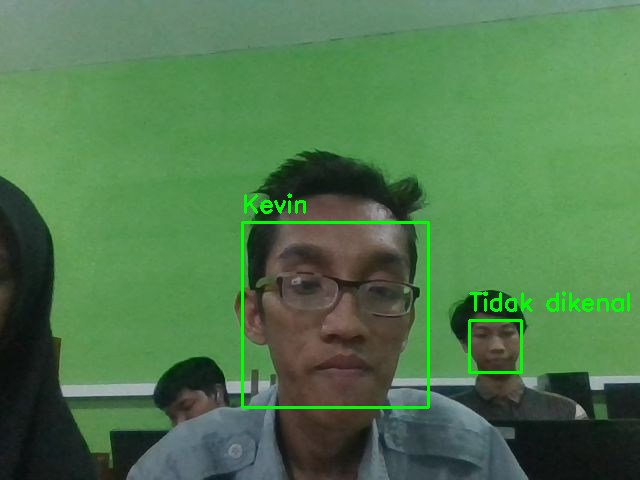

In [ ]:
!pip install face_recognition opencv-python

import cv2
import face_recognition
import numpy as np

from IPython.display import display, Javascript
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow

from base64 import b64decode

# =====================================
# FOTO REFERENSI
# =====================================
foto_kevin = face_recognition.load_image_file("kevin.jpg")

encoding_kevin = face_recognition.face_encodings(
    foto_kevin
)[0]

# =====================================
# FUNCTION WEBCAM COLAB
# =====================================
def take_photo(filename='photo.jpg', quality=0.8):

    js = Javascript('''
    async function takePhoto(quality) {

      const div = document.createElement('div');
      const capture = document.createElement('button');

      capture.textContent = 'Scan Wajah';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';

      const stream = await navigator.mediaDevices.getUserMedia({
        video: true
      });

      document.body.appendChild(div);
      div.appendChild(video);

      video.srcObject = stream;

      await video.play();

      google.colab.output.setIframeHeight(
          document.body.scrollHeight,
          true
      );

      await new Promise((resolve) =>
          capture.onclick = resolve
      );

      const canvas = document.createElement('canvas');

      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas.getContext('2d').drawImage(
          video,
          0,
          0
      );

      stream.getTracks().forEach(track => track.stop());

      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')

    display(js)

    data = eval_js('takePhoto({})'.format(quality))

    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

# =====================================
# AMBIL FOTO WEBCAM
# =====================================
foto_test = take_photo()

# =====================================
# LOAD FOTO HASIL WEBCAM
# =====================================
img_test = face_recognition.load_image_file(
    foto_test
)

lokasi_wajah = face_recognition.face_locations(
    img_test
)

encoding_test = face_recognition.face_encodings(
    img_test,
    lokasi_wajah
)

img = cv2.cvtColor(
    img_test,
    cv2.COLOR_RGB2BGR
)

# =====================================
# FACE RECOGNITION
# =====================================
for (top, right, bottom, left), face_encoding in zip(
    lokasi_wajah,
    encoding_test
):

    hasil = face_recognition.compare_faces(
        [encoding_kevin],
        face_encoding
    )

    nama = "Tidak dikenal"

    if hasil[0]:
        nama = "Kevin"

    cv2.rectangle(
        img,
        (left, top),
        (right, bottom),
        (0,255,0),
        2
    )

    cv2.putText(
        img,
        nama,
        (left, top - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0,255,0),
        2
    )

# =====================================
# TAMPILKAN HASIL
# =====================================
cv2_imshow(img)

**Sistem Absensi**

<IPython.core.display.Javascript object>

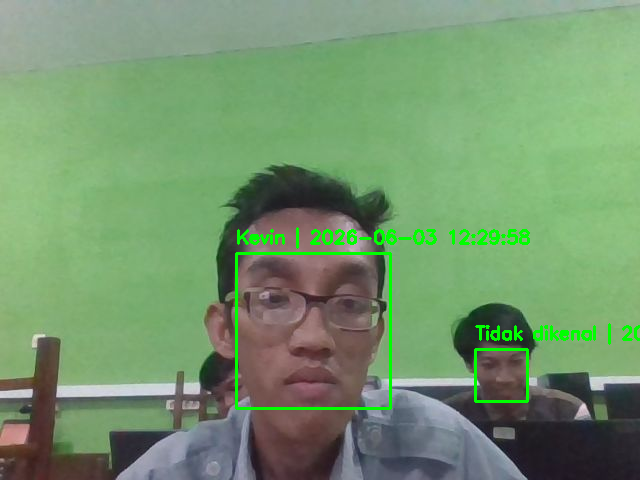

Absensi berhasil disimpan
[{'Nama': 'Kevin', 'Waktu': '2026-06-03 12:29:58', 'Status': 'Hadir'}]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install face_recognition opencv-python pandas

import cv2
import face_recognition
import pandas as pd

from datetime import datetime

from IPython.display import display, Javascript
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow

from base64 import b64decode
from google.colab import files

# =====================================
# FOTO REFERENSI
# =====================================
foto_kevin = face_recognition.load_image_file(
    "/content/kevin.jpg"
)

encoding_kevin = face_recognition.face_encodings(
    foto_kevin
)[0]

# =====================================
# FUNCTION WEBCAM
# =====================================
def take_photo(filename='photo.jpg', quality=0.8):

    js = Javascript('''
    async function takePhoto(quality) {

      const div = document.createElement('div');

      const capture = document.createElement('button');

      capture.textContent = 'Scan Absensi';

      div.appendChild(capture);

      const video = document.createElement('video');

      video.style.display = 'block';

      const stream = await navigator.mediaDevices.getUserMedia({
        video: true
      });

      document.body.appendChild(div);

      div.appendChild(video);

      video.srcObject = stream;

      await video.play();

      google.colab.output.setIframeHeight(
          document.body.scrollHeight,
          true
      );

      await new Promise((resolve) =>
          capture.onclick = resolve
      );

      const canvas = document.createElement('canvas');

      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas.getContext('2d').drawImage(
          video,
          0,
          0
      );

      stream.getTracks().forEach(track => track.stop());

      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')

    display(js)

    data = eval_js('takePhoto({})'.format(quality))

    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

# =====================================
# AMBIL FOTO WEBCAM
# =====================================
foto_test = take_photo()

# =====================================
# LOAD FOTO TEST
# =====================================
img_test = face_recognition.load_image_file(
    foto_test
)

lokasi_wajah = face_recognition.face_locations(
    img_test
)

encoding_test = face_recognition.face_encodings(
    img_test,
    lokasi_wajah
)

img = cv2.cvtColor(
    img_test,
    cv2.COLOR_RGB2BGR
)

# =====================================
# LIST ABSENSI
# =====================================
data_absensi = []

# =====================================
# FACE RECOGNITION
# =====================================
for (top, right, bottom, left), face_encoding in zip(
    lokasi_wajah,
    encoding_test
):

    hasil = face_recognition.compare_faces(
        [encoding_kevin],
        face_encoding
    )

    nama = "Tidak dikenal"

    waktu = datetime.now().strftime(
        "%Y-%m-%d %H:%M:%S"
    )

    if hasil[0]:
        nama = "Kevin"

        data_absensi.append({
            "Nama": nama,
            "Waktu": waktu,
            "Status": "Hadir"
        })

    # =================================
    # TAMPILKAN KOTAK
    # =================================
    cv2.rectangle(
        img,
        (left, top),
        (right, bottom),
        (0,255,0),
        2
    )

    # =================================
    # TAMPILKAN NAMA + WAKTU
    # =================================
    text = f"{nama} | {waktu}"

    cv2.putText(
        img,
        text,
        (left, top - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0,255,0),
        2
    )

# =====================================
# TAMPILKAN HASIL
# =====================================
cv2_imshow(img)

# =====================================
# SIMPAN CSV
# =====================================
df = pd.DataFrame(data_absensi)

csv_file = "absensi.csv"

df.to_csv(csv_file, index=False)

print("Absensi berhasil disimpan")
print(data_absensi)

# =====================================
# DOWNLOAD CSV
# =====================================
files.download(csv_file)


Library apa saja yang digunakan dan fungsinya untuk apa?

face_recognition: Library utama untuk mendeteksi wajah, mengambil encoding wajah, dan membandingkan apakah wajah dikenali atau tidak.
OpenCV (cv2): Digunakan untuk memproses dan menampilkan gambar, seperti membuat kotak pada wajah dan menampilkan nama.
NumPy: Mengolah data numerik berupa array piksel yang digunakan dalam proses encoding wajah.
IPython.display: Menampilkan elemen JavaScript di Google Colab untuk mengaktifkan kamera.
google.colab.output: Menjalankan kode JavaScript (webcam) dari Python.
google.colab.patches (cv2_imshow): Menampilkan gambar hasil deteksi di Google Colab.
base64: Mengubah hasil foto dari webcam (format base64) menjadi file gambar yang bisa diproses.

**4. Gunakan library CNN citra komputer, dan ribuan gambar kucing dan anjing agar komputer bisa mendeteksi jenis kucing atau anjing.**

**bagian A : Install Library, download dataset dan Traning Model**

In [ ]:
!pip install opendatasets --quiet

import os
import zipfile
import opendatasets as od
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Unduh dataset
# Saat dijalankan, program akan meminta Username dan Key dari akun Kaggle Anda
dataset_url = "https://www.kaggle.com/datasets/karakaggle/kaggle-cat-vs-dog-dataset"
od.download(dataset_url)

# Tentukan jalur folder hasil ekstraksi dataset
base_dir = "kaggle-cat-vs-dog-dataset/kagglecatsanddogs_3367a/PetImages"
cat_dir = os.path.join(base_dir, "Cat")
dog_dir = os.path.join(base_dir, "Dog")

# data cleaning (bersihkan data korup)
def bersihkan_gambar_rusak(folder):
    """Menyeleksi dan menghapus file gambar tiruan/cacat agar model tidak eror"""
    for root, _, files in os.walk(folder):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                with open(file_path, "rb") as f:
                    is_jfif = b"JFIF" in f.read(10)
                if not is_jfif:
                    os.remove(file_path)
            except:
                os.remove(file_path)

print("\nSedang membersihkan data dari file gambar yang rusak...")
bersihkan_gambar_rusak(cat_dir)
bersihkan_gambar_rusak(dog_dir)

# data prepocessing & generator
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    base_dir, target_size=(150, 150), batch_size=32, class_mode='binary', subset='training'
)
val_generator = datagen.flow_from_directory(
    base_dir, target_size=(150, 150), batch_size=32, class_mode='binary', subset='validation'
)

# arsitektur cnn
model = Sequential([
    # Blok Konvolusi 1 & Max Pooling
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    # Blok Konvolusi 2 & Max Pooling
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Blok Konvolusi 3 & Max Pooling
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Meratakan matriks 2D menjadi array linear 1D
    Flatten(),
    Dropout(0.5),

    # Fully Connected Layer (Jaringan Saraf Inti)
    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# training model agar akurat
print("\n--- Memulai Proses Training CNN Maksimal (5 Epochs) ---")
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),  # Membaca seluruh total steps data Kaggle
    epochs=5,                              # Dilatih sebanyak 5 putaran penuh
    validation_data=val_generator,
    validation_steps=len(val_generator)
)
print("--- Training Selesai Sempurna! ---")

# simpan model
model.save("model_hewan_kaggle.h5")
print("model disimpan dengan nama 'model_hewan_kaggle.h5'!")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: kevinandrianpolitama
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/karakaggle/kaggle-cat-vs-dog-dataset


100%|██████████| 787M/787M [00:11<00:00, 74.2MB/s]




Sedang membersihkan data dari file gambar yang rusak...
Found 18535 images belonging to 2 classes.
Found 4632 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

...

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)


--- Memulai Proses Training CNN Maksimal (5 Epochs) ---
Epoch 1/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 178s 295ms/step - accuracy: 0.5567 - loss: 0.6977 - val_accuracy: 0.6166 - val_loss: 0.6602
Epoch 2/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 157s 271ms/step - accuracy: 0.6092 - loss: 0.6597 - val_accuracy: 0.6492 - val_loss: 0.6361
Epoch 3/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 158s 271ms/step - accuracy: 0.6588 - loss: 0.6226 - val_accuracy: 0.6865 - val_loss: 0.5945
Epoch 4/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 156s 269ms/step - accuracy: 0.6970 - loss: 0.5720 - val_accuracy: 0.7174 - val_loss: 0.5494
Epoch 5/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 156s 269ms/step - accuracy: 0.7189 - loss: 0.5516 - val_accuracy: 0.7545 - val_loss: 0.5029


--- Training Selesai Sempurna! ---
model disimpan dengan nama 'model_hewan_kaggle.h5'!


**Versi Upload Manual**

🧠 Mengaktifkan model yang Sudah Terlatih...


✅ model Aktif! Siap mendeteksi gambar.

unggah gambar kucing / anjing


Saving 1006.jpg to 1006.jpg

"sedang menganalisis piksel dan bentuk gambar..."
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 653ms/step


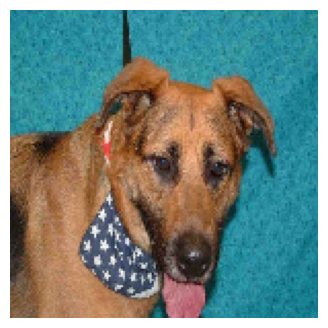

💬 "Gambar ini adalah ANJING!"
   (Tingkat Keyakinan Analisis: 85.01%)


In [ ]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
from google.colab import files
from tensorflow.keras.preprocessing import image

nama_model = "model_hewan_kaggle.h5"

# Memastikan file hasil training dari Bagian A sudah terkunci di sistem
if os.path.exists(nama_model):
    print("🧠 Mengaktifkan model yang Sudah Terlatih...")
    model_matang = tf.keras.models.load_model(nama_model)
    print("✅ model Aktif! Siap mendeteksi gambar.")

    print("\n" + "="*60)
    print("unggah gambar kucing / anjing")
    print("="*60)

    uploaded = files.upload()

    for nama_asli in uploaded.keys():
        path_terbaca = nama_asli

        # Gaya interaktif komputer sedang berpikir membedah matriks piksel
        print('\n"sedang menganalisis piksel dan bentuk gambar..."')
        time.sleep(1.5)

        # Membuka gambar dan menormalisasi skala array-nya
        img = image.load_img(path_terbaca, target_size=(150, 150))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        # model memprediksi gambar secara langsung dalam hitungan milidetik
        skor_prediksi = model_matang.predict(img_array)

        # Menampilkan gambar yang Anda upload ke layar notebook
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.show()

        # Konversi probabilitas biner ke format teks output persentase
        if skor_prediksi[0][0] > 0.5:
            persentase = skor_prediksi[0][0] * 100
            print(f'💬 "Gambar ini adalah ANJING!"')
            print(f'   (Tingkat Keyakinan Analisis: {persentase:.2f}%)')
        else:
            persentase = (1 - skor_prediksi[0][0]) * 100
            print(f'💬 "Gambar ini adalah KUCING!"')
            print(f'   (Tingkat Keyakinan Analisis: {persentase:.2f}%)')
else:
    print("File model_hewan_kaggle.h5 tidak ditemukan! Silakan jalankan sel BAGIAN A terlebih dahulu sebanyak 1 kali untuk membuat berkas modelnya.")


**Versi Otomatis akan mendeteksi gambar random dengan jeda 5 detik**

 🎲 DETEKSI OTOMATIS BERKALA - GAMBAR KE-1 🎲 
📂 [Label Asli Dataset: ANJING]
"Sedang menganalisis piksel dan bentuk gambar..."


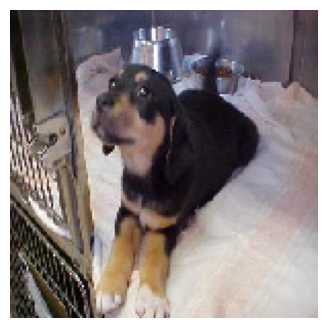

💬 "Sistem mendeteksi gambar ini sebagai ANJING!"
⚠️ Gambar dilewati karena masalah pemuatan berkas.

🛑 Deteksi berkala berhasil dihentikan oleh pengguna!


In [ ]:
import os
import random
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.preprocessing import image
from IPython.display import clear_output

nama_model = "model_hewan_kaggle.h5"
base_dataset_dir = "kaggle-cat-vs-dog-dataset/kagglecatsanddogs_3367a/PetImages"

# 1. Memastikan file hasil training dari Bagian A sudah terkunci di sistem
if os.path.exists(nama_model):
    print("🧠 Mengaktifkan model yang Sudah Terlatih...")
    model_matang = tf.keras.models.load_model(nama_model)
    print("✅ model Aktif!")
    time.sleep(1)

    # Tentukan path folder kucing dan anjing dari dataset asli Anda
    folder_cat = os.path.join(base_dataset_dir, "Cat")
    folder_dog = os.path.join(base_dataset_dir, "Dog")

    # Pastikan foldernya ada di Colab Anda
    if not os.path.exists(folder_cat) or not os.path.exists(folder_dog):
        print(f"❌ Folder dataset tidak ditemukan di path: {base_dataset_dir}")
        print("💡 Silakan jalankan ulang kode pengunduhan dataset Anda terlebih dahulu.")
    else:
        print("✅ Dataset terdeteksi! Memulai perulangan deteksi acak 5 detik...")
        time.sleep(1)

        putaran = 1
        try:
            while True:
                # Bersihkan layar lama agar hasil analisis gambar berikutnya rapi di atas
                clear_output(wait=True)

                print("="*60)
                print(f" 🎲 DETEKSI OTOMATIS BERKALA - GAMBAR KE-{putaran} 🎲 ")
                print("="*60)

                # Pilih kategori acak (50% Kucing, 50% Anjing)
                kategori_terpilih = random.choice([folder_cat, folder_dog])
                label_asli = "KUCING" if kategori_terpilih == folder_cat else "ANJING"

                # Ambil daftar file gambar valid di folder tersebut
                ekstensi_gambar = ('.png', '.jpg', '.jpeg')
                daftar_gambar = [f for f in os.listdir(kategori_terpilih) if f.lower().endswith(ekstensi_gambar)]

                if len(daftar_gambar) == 0:
                    continue

                # Pilih satu gambar secara acak
                gambar_acak = random.choice(daftar_gambar)
                path_terbaca = os.path.join(kategori_terpilih, gambar_acak)

                print(f"📂 [Label Asli Dataset: {label_asli}]")
                print('"Sedang menganalisis piksel dan bentuk gambar..."')

                try:
                    # Membuka gambar dan menormalisasi skala array-nya
                    img = image.load_img(path_terbaca, target_size=(150, 150))
                    img_array = image.img_to_array(img)
                    img_array = np.expand_dims(img_array, axis=0) / 255.0

                    # Model memprediksi gambar secara langsung
                    skor_prediksi = model_matang.predict(img_array, verbose=0)

                    # Menampilkan gambar ke layar notebook
                    plt.figure(figsize=(4, 4))
                    plt.imshow(img)
                    plt.axis('off')
                    plt.show()

                    # Konversi probabilitas biner ke format teks output persentase
                    # Bergantung pada bagaimana struktur kelas saat training Anda dikunci
                    if skor_prediksi > 0.5:
                        persentase = skor_prediksi * 100
                        print(f'💬 "Sistem mendeteksi gambar ini sebagai ANJING!"')
                        print(f'   (Tingkat Keyakinan Analisis: {persentase:.2f}%)')
                    else:
                        persentase = (1 - skor_prediksi) * 100
                        print(f'💬 "Sistem mendeteksi gambar ini sebagai KUCING!"')
                        print(f'   (Tingkat Keyakinan Analisis: {persentase:.2f}%)')

                    # Evaluasi akurasi prediksi sistem
                    tebakan_tepat = (skor_prediksi > 0.5 and label_asli == "ANJING") or (skor_prediksi <= 0.5 and label_asli == "KUCING")
                    if tebakan_tepat:
                        print("🎯 HASIL PREDIKSI: BENAR!")
                    else:
                        print("❌ HASIL PREDIKSI: SALAH!")

                except Exception as e:
                    # Lewati jika ada file corrupt di dataset bawaan kaggle
                    print(f"⚠️ Gambar dilewati karena masalah pemuatan berkas.")
                    time.sleep(1)
                    continue

                print("\n⏳ Menunggu 5 detik untuk memuat gambar selanjutnya...")
                print("(Klik tombol STOP bulat di sebelah kiri sel untuk menyudahi proses)")

                putaran += 1
                time.sleep(20)  # Jeda waktu 5 detik sebelum gambar berikutnya diacak

        except KeyboardInterrupt:
            print("\n🛑 Deteksi berkala berhasil dihentikan oleh pengguna!")
else:
    print(f"File {nama_model} tidak ditemukan! Silakan jalankan sel BAGIAN A terlebih dahulu sebanyak 1 kali untuk membuat berkas modelnya.")


**Username : kevinandrianpolitama**

**Api Token : KGAT_c52f27870c92f5ad39fe0d39d1f049ac**

**NOTE : Untuk Runtime gunakan T4(Python 3)**

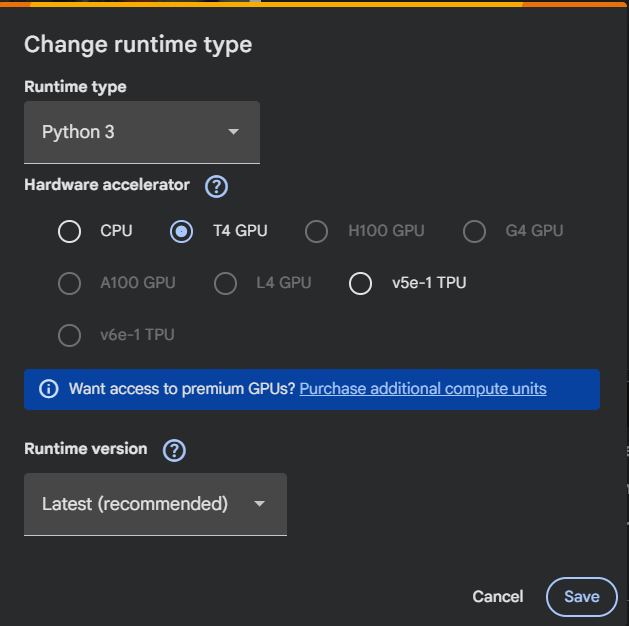